In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [11]:
import os
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

DATA_DIR='/kaggle/input/competitions/shopee-product-matching'
df = pd.read_csv(f'{DATA_DIR}/train.csv')

# Fast ground-truth mapping for F1 evaluation
target_dict = df.groupby('label_group')['posting_id'].apply(set).to_dict()
targets = [target_dict[lg] for lg in df['label_group']]
posting_ids = df['posting_id'].values

def evaluate_predictions(preds_list, truth_list):
    f1s, precs, recs = [], [], []
    for preds, truth in zip(preds_list, truth_list):
        inter = len(preds & truth)
        p = inter / len(preds)
        r = inter / len(truth)
        f1 = (2 * inter) / (len(preds) + len(truth))
        precs.append(p)
        recs.append(r)
        f1s.append(f1)
    return {'f1': np.mean(f1s), 'precision': np.mean(precs), 'recall': np.mean(recs)}


Using device: cuda


In [19]:
# pHash exact match baseline
phash_dict = df.groupby('image_phash')['posting_id'].apply(set).to_dict()
phash_preds = [phash_dict[p] for p in df['image_phash']]

phash_metrics = evaluate_predictions(phash_preds, targets)
print(f"pHash Baseline -> F1: {phash_metrics['f1']:.4f}, Prec: {phash_metrics['precision']:.4f}, Rec: {phash_metrics['recall']:.4f}")


pHash Baseline -> F1: 0.5531, Prec: 0.9941, Rec: 0.4222


In [17]:
import os
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm.auto import tqdm

# 1. Dataset class for loading product images
class ShopeeImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# 2. Image Preprocessing (Standard ImageNet normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. DataLoader
dataset = ShopeeImageDataset(df, f'{DATA_DIR}/train_images', transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

# 4. Load pretrained ResNet50 (using modern weights parameter)
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet.fc = torch.nn.Identity()  # Strip classifier to output 2048-dim embeddings
resnet = resnet.to(device).eval()

# 5. Extract embeddings on GPU
embeddings = []
with torch.no_grad():
    for imgs in tqdm(loader, desc="Extracting Image Embeddings"):
        imgs = imgs.to(device)
        feat = resnet(imgs)
        # L2-normalize vectors so dot product equals cosine similarity
        feat = torch.nn.functional.normalize(feat, p=2, dim=1)
        embeddings.append(feat.cpu().numpy())

image_embeddings = np.vstack(embeddings)
print("✓ Done! Image embeddings shape:", image_embeddings.shape)


Extracting Image Embeddings:   0%|          | 0/536 [00:00<?, ?it/s]

✓ Done! Image embeddings shape: (34250, 2048)


In [18]:
thresholds = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
chunk_size = 2000

for th in thresholds:
    f1_list, p_list, r_list = [], [], []
    for start in range(0, 5000, chunk_size):
        end = min(start + chunk_size, 5000)
        chunk = image_embeddings[start:end]
        sim = chunk @ image_embeddings.T  # Cosine similarity matrix
        
        for i in range(end - start):
            matches = set(posting_ids[np.where(sim[i] >= th)[0]])
            matches.add(posting_ids[start + i])
            truth = targets[start + i]
            
            inter = len(matches & truth)
            f1_list.append(2 * inter / (len(matches) + len(truth)))
            p_list.append(inter / len(matches))
            r_list.append(inter / len(truth))
            
    print(f"ResNet50 @ Threshold {th:.2f} -> F1: {np.mean(f1_list):.4f} | Prec: {np.mean(p_list):.4f} | Rec: {np.mean(r_list):.4f}")


ResNet50 @ Threshold 0.65 -> F1: 0.3744 | Prec: 0.3836 | Rec: 0.7608
ResNet50 @ Threshold 0.70 -> F1: 0.4896 | Prec: 0.5592 | Rec: 0.7064
ResNet50 @ Threshold 0.75 -> F1: 0.5775 | Prec: 0.7226 | Rec: 0.6579
ResNet50 @ Threshold 0.80 -> F1: 0.6300 | Prec: 0.8544 | Rec: 0.6113
ResNet50 @ Threshold 0.85 -> F1: 0.6447 | Prec: 0.9338 | Rec: 0.5681
ResNet50 @ Threshold 0.90 -> F1: 0.6283 | Prec: 0.9731 | Rec: 0.5238


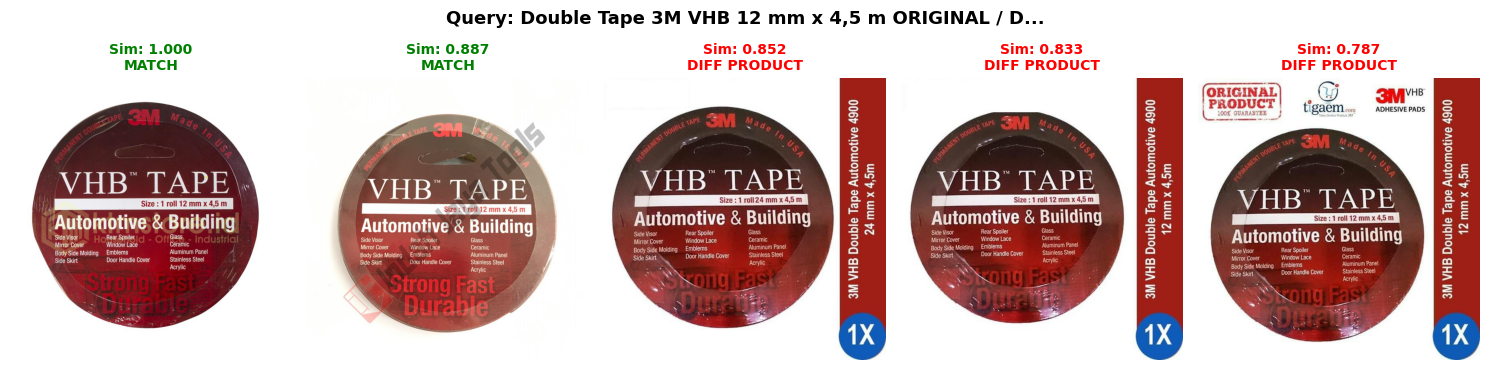

In [25]:
def show_nearest_neighbors(query_idx, top_k=5):
    query_emb = image_embeddings[query_idx]
    sims = image_embeddings @ query_emb
    top_indices = np.argsort(sims)[::-1][:top_k]
    
    fig, axes = plt.subplots(1, top_k, figsize=(15, 3.5))
    for ax, idx in zip(axes, top_indices):
        img_path = os.path.join(f'{DATA_DIR}/train_images', df.iloc[idx]['image'])
        img = Image.open(img_path)
        is_match = df.iloc[idx]['label_group'] == df.iloc[query_idx]['label_group']
        
        ax.imshow(img)
        ax.axis('off')
        color = 'green' if is_match else 'red'
        ax.set_title(f"Sim: {sims[idx]:.3f}\n{'MATCH' if is_match else 'DIFF PRODUCT'}", color=color, fontweight='bold', fontsize=10)
    plt.suptitle(f"Query: {df.iloc[query_idx]['title'][:45]}...", fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


# Visualize nearest neighbors for a sample item
show_nearest_neighbors(1, top_k=5)
